# EGX360 — THE DEEP QUANT MODEL With Accuracy 89
### Enhancing Down-Trend Detection & Bias Control in the Egyptian Stock Exchange

In [99]:
import tensorflow as tf
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Success! GPU found: {gpu_devices}")
else:
    print("Still not working. Check PATH or CUDA version.")

Still not working. Check PATH or CUDA version.


In [100]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')
import os

## 2. Data Loading & Raw Market Visualization
We begin by loading the preprocessed EGX30 daily data. Financial time series data is notoriously noisy. Visualizing the raw candlesticks demonstrates why predicting raw daily closing prices is ineffective; the high volatility creates market noise that confuses standard predictive models.

In [101]:
current_dir = os.getcwd()

file_path = os.path.join(current_dir, "data", "EGX30_Final_v9.csv")
df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None).dt.normalize()
df.set_index('timestamp', inplace=True)


In [102]:
ir_path = os.path.join(current_dir, "data", "cbe_interest_rate.csv")
if os.path.exists(ir_path):
    ir_df = pd.read_csv(ir_path)
    ir_df['Date'] = pd.to_datetime(ir_df['Date']).dt.normalize()
    ir_df.set_index('Date', inplace=True)
    df = df.join(ir_df, how='left')
    df['Interest_Rate'] = df['Interest_Rate'].ffill().bfill()
    df['IR_Change'] = df['Interest_Rate'].diff().fillna(0)
    print("Interest Rates Merged.")

print(f"Final Shape: {df.shape}")

Interest Rates Merged.
Final Shape: (6882, 16)


In [103]:
print(f"Missing values: {df.isnull().sum()}")
df.dropna(inplace=True)
df.sort_index(inplace=True)

Missing values: open                  0
high                  0
low                   0
close                 0
volume                0
usd_egp_rate          0
close_usd             0
log_ret_usd           1
price_velocity_usd    2
gold_usd              0
gold_egp              0
gold_log_ret          1
gold_velocity         2
gold_ret_lag1         2
Interest_Rate         0
IR_Change             0
dtype: int64


In [104]:
df.tail()


,open,high,low,close,volume,usd_egp_rate,close_usd,log_ret_usd,price_velocity_usd,gold_usd,gold_egp,gold_log_ret,gold_velocity,gold_ret_lag1,Interest_Rate,IR_Change
timestamp,,,,,,,,,,,,,,,,
2026-03-03,47558.1,47699.0,46391.2,46725.8,390722000,49.189800,949.908309,-0.050957,-0.049851,5107.399902,251231.981057,-0.005480,-0.023007,0.017527,19.0,0.0
2026-03-04,46793.2,46881.1,44587.7,46452.1,424028000,49.849499,931.846882,-0.019197,0.031760,5120.200195,255239.413230,0.015825,0.021305,-0.005480,19.0,0.0
2026-03-05,46982.8,47753.5,46452.1,47516.4,443405000,50.157398,947.345789,0.016496,0.035693,5065.299805,254062.259427,-0.004623,-0.020448,0.015825,19.0,0.0
2026-03-08,47695.6,47723.5,46709.0,46774.2,523463000,50.157398,932.548371,-0.015743,-0.032239,5065.299805,254062.259427,0.000000,0.004623,-0.004623,19.0,0.0
2026-03-09,47035.2,47087.9,45848.5,46414.8,575019000,50.730816,914.923192,-0.019081,-0.003338,5091.500000,258295.949091,0.016527,0.016527,0.000000,19.0,0.0


In [105]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6880 entries, 1998-01-05 to 2026-03-09
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   open                6880 non-null   float64
 1   high                6880 non-null   float64
 2   low                 6880 non-null   float64
 3   close               6880 non-null   float64
 4   volume              6880 non-null   int64  
 5   usd_egp_rate        6880 non-null   float64
 6   close_usd           6880 non-null   float64
 7   log_ret_usd         6880 non-null   float64
 8   price_velocity_usd  6880 non-null   float64
 9   gold_usd            6880 non-null   float64
 10  gold_egp            6880 non-null   float64
 11  gold_log_ret        6880 non-null   float64
 12  gold_velocity       6880 non-null   float64
 13  gold_ret_lag1       6880 non-null   float64
 14  Interest_Rate       6880 non-null   float64
 15  IR_Change           6880 non-null   float64
dtyp

## Step 1: Visualizing EGX30 vs Macroeconomic Drivers

In [106]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


fig_macro = make_subplots(rows=3, cols=1, shared_xaxes=True, 
                          vertical_spacing=0.05,
                          subplot_titles=('EGX30 Close Price', 'USD/EGP Exchange Rate', 'Gold Price (EGP)'))

# 1. Egx30
fig_macro.add_trace(go.Scatter(x=df.index, y=df['close'], mode='lines', name='EGX30', line=dict(color='black')), row=1, col=1)

# 2. usd
fig_macro.add_trace(go.Scatter(x=df.index, y=df['usd_egp_rate'], mode='lines', name='USD/EGP', line=dict(color='green')), row=2, col=1)

# 3. gold
fig_macro.add_trace(go.Scatter(x=df.index, y=df['gold_egp'], mode='lines', name='Gold (EGP)', line=dict(color='goldenrod')), row=3, col=1)

fig_macro.update_layout(height=800, title_text="Macroeconomic Trends in Egypt (1998 - Present)", template='plotly_white', hovermode='x unified')
fig_macro.show()

## Step 2: Macroeconomic Correlation Analysis

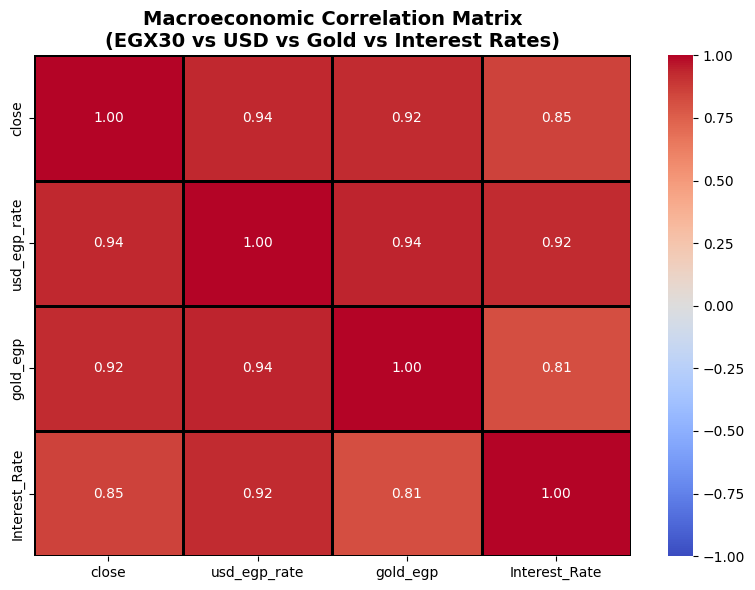

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns


# اختيار العواميد الاقتصادية وحساب الترابط
macro_cols = ['close', 'usd_egp_rate', 'gold_egp', 'Interest_Rate']
corr_matrix = df[macro_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1, linecolor='black', fmt=".2f")
plt.title("Macroeconomic Correlation Matrix\n(EGX30 vs USD vs Gold vs Interest Rates)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3: Statistical Properties of Returns (Market Noise)

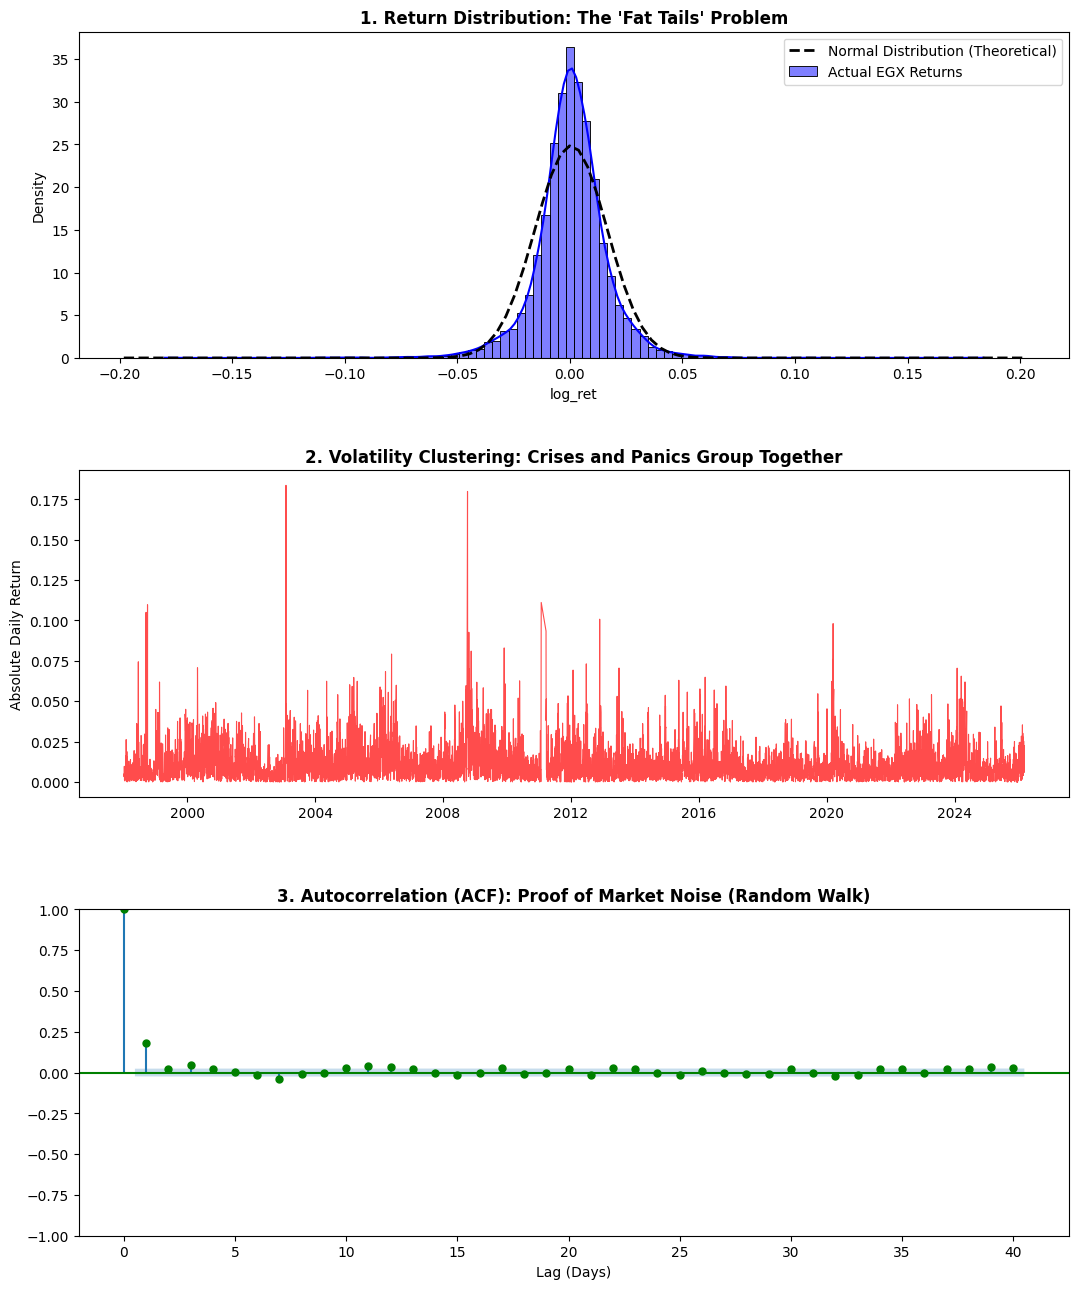

In [112]:
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf


# حساب العوائد اللوغاريتمية لو مش موجودة
if 'log_ret' not in df.columns:
    df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))

returns = df['log_ret'].dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.tight_layout(pad=6.0)

# 1. (Fat Tails)
sns.histplot(returns, bins=100, kde=True, stat="density", ax=axes[0], color='blue', alpha=0.5, label='Actual EGX Returns')
mu, std = stats.norm.fit(returns)
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'k', linewidth=2, linestyle='dashed', label='Normal Distribution (Theoretical)')
axes[0].set_title("1. Return Distribution: The 'Fat Tails' Problem", fontsize=12, fontweight='bold')
axes[0].legend()

# 2.(Volatility Clustering)
axes[1].plot(returns.index, np.abs(returns), color='red', alpha=0.7, linewidth=0.8)
axes[1].set_title("2. Volatility Clustering: Crises and Panics Group Together", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Absolute Daily Return")

# 3.(Autocorrelation)
plot_acf(returns, lags=40, ax=axes[2], alpha=0.05, color='green')
axes[2].set_title("3. Autocorrelation (ACF): Proof of Market Noise (Random Walk)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Lag (Days)")

plt.show()


## Advanced Quant Proofs (Academic Justification)

In [113]:
from statsmodels.tsa.stattools import adfuller


# 1. Augmented Dickey-Fuller (ADF) Test 
adf_result = adfuller(df['close'].dropna())
p_value = adf_result[1]


# 2. Maximum Drawdown (MDD)
cumulative_returns = (1 + returns).cumprod()
running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_max) / running_max
max_drawdown = drawdown.min() * 100

# 3. Drawdown 
fig_dd = go.Figure()

fig_dd.add_trace(go.Scatter(x=drawdown.index, y=drawdown * 100, 
                            mode='lines', name='Drawdown %', 
                            line=dict(color='darkred', width=1.5),
                            fill='tozeroy', fillcolor='rgba(139, 0, 0, 0.3)'))

fig_dd.update_layout(title='Market Pain Index: Historical Drawdowns (The Danger of Market Noise)',
                     yaxis_title='Drawdown (%)',
                     xaxis_title='Date',
                     height=400,
                     template='plotly_white')

fig_dd.show()

## Extreme Events & Outliers Analysis (Black Swans)

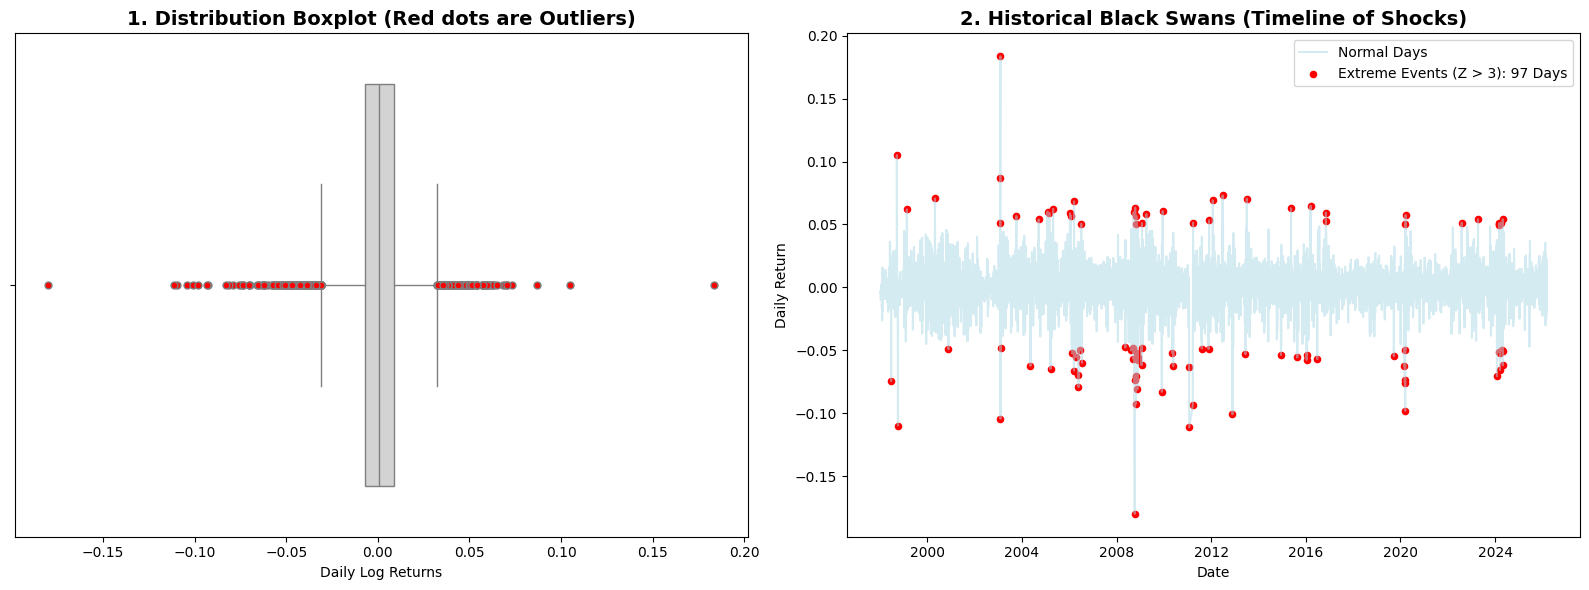

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats


if 'log_ret' not in df.columns:
    df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))

returns = df['log_ret'].dropna()

# z socre
z_scores = np.abs(stats.zscore(returns))
outliers_mask = z_scores > 3
outliers = returns[outliers_mask]


# Outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot 
sns.boxplot(x=returns, ax=axes[0], color='lightgray', flierprops=dict(markerfacecolor='red', marker='o', markersize=5))
axes[0].set_title("1. Distribution Boxplot (Red dots are Outliers)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Daily Log Returns")

# 2. Scatter Plot 
axes[1].plot(returns.index, returns, color='lightblue', alpha=0.5, label='Normal Days')
axes[1].scatter(outliers.index, outliers, color='red', s=20, label=f'Extreme Events (Z > 3): {len(outliers)} Days')
axes[1].set_title("2. Historical Black Swans (Timeline of Shocks)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily Return")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 5: Visualizing the impact of Target Engineering (Smoothing)

In [115]:

sample_noise_df = df.tail(250).copy()
sample_noise_df['EMA_10'] = sample_noise_df['close'].ewm(span=10).mean()

fig_smooth = go.Figure()

fig_smooth.add_trace(go.Scatter(x=sample_noise_df.index, y=sample_noise_df['close'], 
                                mode='lines', name='Noisy Raw Price', 
                                line=dict(color='lightgray', width=1.5)))

fig_smooth.add_trace(go.Scatter(x=sample_noise_df.index, y=sample_noise_df['EMA_10'], 
                                mode='lines', name='Target: EMA 10 (Clean Signal)', 
                                line=dict(color='blue', width=3)))

fig_smooth.update_layout(title='Why We Predict EMA instead of Price: Noise Filtration',
                         yaxis_title='Price (EGP)',
                         xaxis_title='Date',
                         height=500,
                         template='plotly_white')
fig_smooth.show()

## 3. Advanced Feature Engineering (The Quant Indicators)
To make the data machine-readable, we engineer quantitative features. We translate raw price action into mathematical signals representing Trend, Momentum, and Volatility.

### A. Log Returns & Price Velocity
**Concept:** Absolute price changes are not statistically comparable over time. Logarithmic returns stabilize the variance. **Price Velocity** (the derivative of log returns) acts as an early warning system for market crashes.

**Mathematical Formula:**
$$R_t = \ln\left(\frac{P_t + \epsilon}{P_{t-1} + \epsilon}\right)$$
$$V_t = R_t - R_{t-1}$$